# Nhóm 8 - Demo TF-IDF + BM25:
- Hồ Hữu Tây
- Lê Thiên Quân
- Phạm Ngọc Thọ
- Dương Hoàng Việt
# Demo Chapter 11

- TF-IDF + BM25 features
- Using Lightweight BERT fine-tuning (DistilBERT)


## Cài thư viện

In [ ]:
!pip install -q transformers datasets seqeval rank_bm25

import os
import re
import glob
import zipfile
import shutil
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
)

from seqeval.metrics import (
    classification_report as seq_classification_report,
    precision_score as seq_precision_score,
    recall_score as seq_recall_score,
    f1_score as seq_f1_score,
    accuracy_score as seq_accuracy_score,
)

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


## 1. Khai báo đường dẫn và giải nén dữ liệu

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ====== CHỈNH ĐƯỜNG DẪN ZIP Ở ĐÂY ======
ZIP_PATH = "/content/drive/MyDrive/HK_4/CS221_NLP/Datasets/nervlsp2018.zip"

EXTRACT_DIR = "/content/data"

# Xóa folder cũ để tránh lẫn dữ liệu
if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)
os.makedirs(EXTRACT_DIR, exist_ok=True)

# Giải nén file zip chính
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(EXTRACT_DIR)

# Giải nén các file zip con: train/dev/test
nested_zips = glob.glob(os.path.join(EXTRACT_DIR, "**", "*.zip"), recursive=True)

for zp in nested_zips:
    zp_lower = zp.lower()
    base = os.path.basename(zp_lower)

    # bỏ metadata của MacOS nếu có
    if "__macosx" in zp_lower or base.startswith("._"):
        continue

    if "train" in base:
        split = "train"
    elif "dev" in base:
        split = "dev"
    elif "test" in base:
        split = "test"
    else:
        continue

    out_dir = os.path.join(EXTRACT_DIR, split)
    os.makedirs(out_dir, exist_ok=True)

    with zipfile.ZipFile(zp, "r") as zf:
        zf.extractall(out_dir)

print("Nested zip files:", nested_zips)
print("Train files:", len(glob.glob(os.path.join(EXTRACT_DIR, "train", "**", "*.muc"), recursive=True)))
print("Dev files:", len(glob.glob(os.path.join(EXTRACT_DIR, "dev", "**", "*.muc"), recursive=True)))
print("Test files:", len(glob.glob(os.path.join(EXTRACT_DIR, "test", "**", "*.muc"), recursive=True)))


Mounted at /content/drive
Nested zip files: ['/content/data/nervlsp2018/VLSP2018-NER-dev.zip', '/content/data/nervlsp2018/VLSP2018-NER-Test-Domains.zip', '/content/data/nervlsp2018/VLSP2018-NER-train.zip']
Train files: 781
Dev files: 260
Test files: 0


## 2. Parse dữ liệu `.muc` sang BIO format

Dataset này không phải dạng `token label` sẵn.  
Nó là raw text có entity được đánh dấu bằng tag như:

Ta sẽ chuyển thành dạng BIO:

```text
Tổ      B-ORGANIZATION
chức    I-ORGANIZATION
y       I-ORGANIZATION
tế      I-ORGANIZATION
Thế     I-ORGANIZATION
giới    I-ORGANIZATION
```


In [ ]:
TOKEN_PATTERN = re.compile(r"\w+|[^\w\s]", flags=re.UNICODE)
TAG_PATTERN = re.compile(r'<ENAMEX\s+TYPE="([^"]+)">|</ENAMEX>', flags=re.IGNORECASE)

def tokenize_segment(text):
    return TOKEN_PATTERN.findall(text)

def add_segment_tokens(segment, current_type, is_new_entity, tokens, labels):
    seg_tokens = tokenize_segment(segment)

    for tok in seg_tokens:
        if current_type is None:
            labels.append("O")
        else:
            prefix = "B-" if is_new_entity else "I-"
            labels.append(prefix + current_type)
            is_new_entity = False

        tokens.append(tok)

    return is_new_entity

def muc_text_to_bio(text):
    tokens = []
    labels = []

    current_type = None
    is_new_entity = False
    last_idx = 0

    for match in TAG_PATTERN.finditer(text):
        # text trước tag
        segment = text[last_idx:match.start()]
        is_new_entity = add_segment_tokens(
            segment, current_type, is_new_entity, tokens, labels
        )

        # tag mở
        if match.group(1) is not None:
            current_type = match.group(1)
            is_new_entity = True
        # tag đóng
        else:
            current_type = None
            is_new_entity = False

        last_idx = match.end()

    # phần còn lại sau tag cuối
    segment = text[last_idx:]
    add_segment_tokens(segment, current_type, is_new_entity, tokens, labels)

    return tokens, labels

def fix_bio_sequence(labels):
    fixed = []
    prev_type = None

    for lab in labels:
        if lab == "O":
            fixed.append(lab)
            prev_type = None
            continue

        prefix, ent_type = lab.split("-", 1)

        # Nếu sequence bắt đầu bằng I hoặc I không nối đúng entity trước đó,
        # đổi thành B để BIO hợp lệ.
        if prefix == "I" and prev_type != ent_type:
            fixed.append("B-" + ent_type)
        else:
            fixed.append(lab)

        prev_type = ent_type

    return fixed

def split_into_sentences(tokens, labels, max_len=120):
    sentence_tokens = []
    sentence_labels = []

    cur_toks = []
    cur_labs = []

    end_punct = {".", "?", "!", "…"}

    for tok, lab in zip(tokens, labels):
        cur_toks.append(tok)
        cur_labs.append(lab)

        if tok in end_punct or len(cur_toks) >= max_len:
            if len(cur_toks) > 0:
                sentence_tokens.append(cur_toks)
                sentence_labels.append(fix_bio_sequence(cur_labs))
            cur_toks = []
            cur_labs = []

    if len(cur_toks) > 0:
        sentence_tokens.append(cur_toks)
        sentence_labels.append(fix_bio_sequence(cur_labs))

    return sentence_tokens, sentence_labels

def load_split(split_dir, max_len=120):
    all_tokens = []
    all_labels = []

    muc_files = glob.glob(os.path.join(split_dir, "**", "*.muc"), recursive=True)

    for fp in muc_files:
        if "__MACOSX" in fp:
            continue

        with open(fp, encoding="utf-8", errors="ignore") as f:
            text = f.read()

        tokens, labels = muc_text_to_bio(text)
        sents, labs = split_into_sentences(tokens, labels, max_len=max_len)

        all_tokens.extend(sents)
        all_labels.extend(labs)

    return all_tokens, all_labels

train_tokens, train_labels = load_split(os.path.join(EXTRACT_DIR, "train"))
dev_tokens, dev_labels = load_split(os.path.join(EXTRACT_DIR, "dev"))
test_tokens, test_labels = load_split(os.path.join(EXTRACT_DIR, "test"))

print("Train sentences:", len(train_tokens))
print("Dev sentences:", len(dev_tokens))
print("Test sentences:", len(test_tokens))

print("\nExample tokens:")
print(train_tokens[0][:40])
print("\nExample labels:")
print(train_labels[0][:40])


Train sentences: 17242
Dev sentences: 5717
Test sentences: 0

Example tokens:
['Đắm', 'say', 'trước', 'khung', 'cảnh', 'kỳ', 'vĩ', 'của', 'vịnh', 'Vũng', 'Rô', 'Do', 'được', 'bao', 'quanh', 'bởi', 'ba', 'dãy', 'núi', 'cao', 'hiểm', 'trở', ',', 'vịnh', 'Vũng', 'Rô', 'của', 'Phú', 'Yên', 'là', 'nơi', 'có', 'khung', 'cảnh', 'thiên', 'nhiên', 'hùng', 'vĩ', 'khiến', 'lòng']

Example labels:
['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOCATION', 'I-LOCATION', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOCATION', 'I-LOCATION', 'O', 'B-LOCATION', 'I-LOCATION', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


## 3. Plot phân bố label trong train set

,label,count
0,O,447605
1,B-LOCATION,9136
2,I-LOCATION,9093
6,I-ORGANIZATION,7714
3,B-PERSON,6504
4,I-PERSON,6423
5,B-ORGANIZATION,5135
8,I-MISCELLANEOUS,1770
7,B-MISCELLANEOUS,807


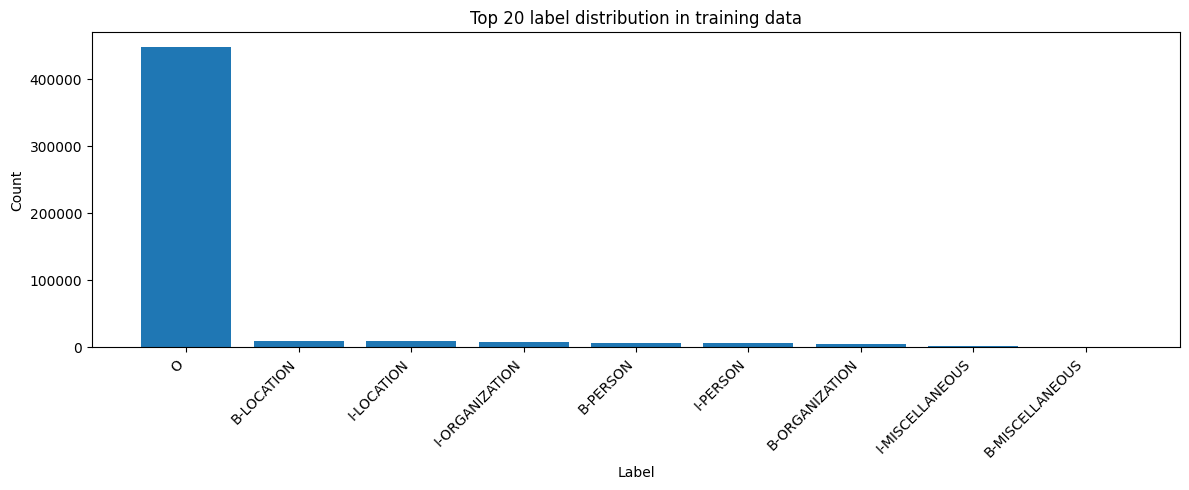

In [ ]:
label_counter = Counter(label for sent in train_labels for label in sent)

label_df = (
    pd.DataFrame(label_counter.items(), columns=["label", "count"])
    .sort_values("count", ascending=False)
)

display(label_df.head(20))

plt.figure(figsize=(12, 5))
plt.bar(label_df["label"].head(20), label_df["count"].head(20))
plt.title("Top 20 label distribution in training data")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 4. TF-IDF và BM25 demo trên corpus câu

Phần này minh họa retrieval scoring:
- TF-IDF dùng vector sparse và cosine similarity.
- BM25 dùng term frequency + document length normalization.


Query example:
Đắm say trước khung cảnh kỳ vĩ của vịnh Vũng Rô Do được bao quanh bởi ba dãy núi cao hiểm trở , vịnh Vũng Rô của Phú Yên là nơi có khung cảnh thiên nhiên hùng vĩ khiến lòng người say đắm .


,rank,doc_id,bm25_score,tfidf_cosine,document
0,1,0,189.451888,1.000000,Đắm say trước khung cảnh kỳ vĩ của vịnh Vũng R...
1,2,3,158.367867,0.876662,Do được bao quanh bởi những dãy núi cao hiểm t...
2,3,1,55.495561,0.294480,"Thuộc địa phận xã Hòa Xuân Nam , huyện Đông Hò..."
3,4,16,49.151139,0.363475,Một số hình ảnh khác về vịnh Vũng Rô .
4,5,14,46.615118,0.285193,"Ngoài tiềm năng du lịch , vịnh Vũng Rô là một ..."
5,6,8,46.179339,0.257092,"Không chỉ là thắng cảnh đẹp , vịnh Vũng Rô còn..."
6,7,15,41.800010,0.242035,"Nhằm khai thác lợi thế này , cảng Vũng Rô và k..."
7,8,7,40.511194,0.246543,"Trong lòng vịnh có nhiều loại tôm cá trú ngụ ,..."
8,9,6,38.430345,0.155439,Ven bờ vịnh Vũng Rô có nhiều bãi cát vừa và nh...
9,10,255,35.805767,0.175230,"Hoa mọc dày xung quanh sườn núi , tạo thành th..."


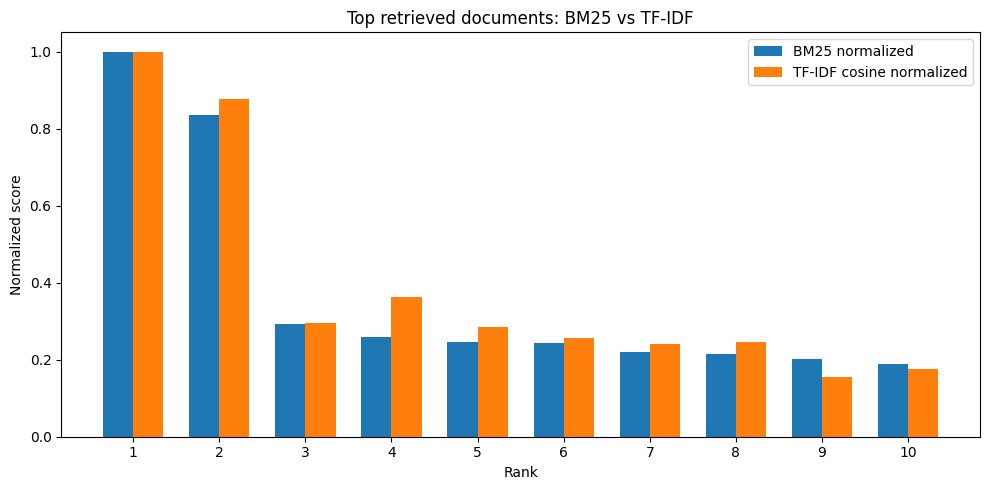

In [ ]:
# Chuyển sentence token list thành text document
train_docs = [" ".join(tokens) for tokens in train_tokens]
test_docs = [" ".join(tokens) for tokens in test_tokens]

# Để demo retrieval nhanh, dùng một phần corpus nếu corpus quá lớn
IR_CORPUS_SIZE = min(5000, len(train_docs))
ir_docs = train_docs[:IR_CORPUS_SIZE]

query = test_docs[0] if len(test_docs) > 0 else ir_docs[0]
print("Query example:")
print(query[:500])

# ===== TF-IDF cosine =====
tfidf_vectorizer = TfidfVectorizer(
    max_features=20000,
    lowercase=False,
    token_pattern=r"(?u)\b\w+\b"
)

tfidf_matrix = tfidf_vectorizer.fit_transform(ir_docs)
query_vec = tfidf_vectorizer.transform([query])
tfidf_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

# ===== BM25 =====
tokenized_corpus = [doc.split() for doc in ir_docs]
bm25 = BM25Okapi(tokenized_corpus)
bm25_scores = bm25.get_scores(query.split())

# lấy top theo BM25 để minh họa
top_k = 10
top_idx = np.argsort(bm25_scores)[::-1][:top_k]

retrieval_df = pd.DataFrame({
    "rank": list(range(1, top_k + 1)),
    "doc_id": top_idx,
    "bm25_score": bm25_scores[top_idx],
    "tfidf_cosine": tfidf_scores[top_idx],
    "document": [ir_docs[i][:200] for i in top_idx]
})

display(retrieval_df)

plt.figure(figsize=(10, 5))
x = np.arange(top_k)
width = 0.35

# Normalize để so sánh hình dạng vì BM25 và cosine khác scale
bm25_norm = retrieval_df["bm25_score"] / (retrieval_df["bm25_score"].max() + 1e-9)
tfidf_norm = retrieval_df["tfidf_cosine"] / (retrieval_df["tfidf_cosine"].max() + 1e-9)

plt.bar(x - width/2, bm25_norm, width, label="BM25 normalized")
plt.bar(x + width/2, tfidf_norm, width, label="TF-IDF cosine normalized")

plt.title("Top retrieved documents: BM25 vs TF-IDF")
plt.xlabel("Rank")
plt.ylabel("Normalized score")
plt.xticks(x, retrieval_df["rank"])
plt.legend()
plt.tight_layout()
plt.show()


## 5. label mapping

In [ ]:
unique_labels = sorted(set(label for sent in train_labels for label in sent))

label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

print("Number of labels:", len(unique_labels))
print(unique_labels)

train_label_ids = [[label2id[label] for label in sent] for sent in train_labels]
dev_label_ids = [[label2id[label] for label in sent] for sent in dev_labels]
test_label_ids = [[label2id[label] for label in sent] for sent in test_labels]


Number of labels: 9
['B-LOCATION', 'B-MISCELLANEOUS', 'B-ORGANIZATION', 'B-PERSON', 'I-LOCATION', 'I-MISCELLANEOUS', 'I-ORGANIZATION', 'I-PERSON', 'O']


## 6. Tokenization + label alignment

In [22]:
MODEL_NAME = "distilbert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_and_align_labels(token_sequences, label_sequences, max_length=128):
    if len(token_sequences) != len(label_sequences):
        raise ValueError(
            f"Số câu và số label sequence không khớp: "
            f"{len(token_sequences)} tokens vs {len(label_sequences)} labels"
        )

    tokenized_inputs = tokenizer(
        token_sequences,
        is_split_into_words=True,
        truncation=True,
        max_length=max_length,
        padding=False,
    )

    aligned_labels = []

    for i, labels in enumerate(label_sequences):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(labels[word_idx])
            else:
                # Subword sau của cùng 1 từ: bỏ qua khi tính loss
                label_ids.append(-100)

            previous_word_idx = word_idx

        aligned_labels.append(label_ids)

    tokenized_inputs["labels"] = aligned_labels
    return tokenized_inputs


def tokenize_without_labels(token_sequences, max_length=128):
    return tokenizer(
        token_sequences,
        is_split_into_words=True,
        truncation=True,
        max_length=max_length,
        padding=False,
    )


# Train/dev chắc chắn phải có label
train_encodings = tokenize_and_align_labels(train_tokens, train_label_ids)
dev_encodings = tokenize_and_align_labels(dev_tokens, dev_label_ids)

train_dataset = Dataset.from_dict(train_encodings)
dev_dataset = Dataset.from_dict(dev_encodings)

# Test có thể không có label
print("len(test_tokens):", len(test_tokens))
print("len(test_label_ids):", len(test_label_ids))

if len(test_label_ids) == len(test_tokens) and len(test_label_ids) > 0:
    print("Test set có label -> dùng test để evaluate.")
    test_encodings = tokenize_and_align_labels(test_tokens, test_label_ids)
    test_dataset = Dataset.from_dict(test_encodings)
    DEV_HAS_LABELS = True
else:
    print("Test set không có label hoặc label bị rỗng -> chỉ predict test, metric sẽ tính trên dev.")
    test_encodings = tokenize_without_labels(test_tokens)
    test_dataset = Dataset.from_dict(test_encodings)
    DEV_HAS_LABELS = False

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

print(train_dataset)
print(dev_dataset)
print(test_dataset)

len(test_tokens): 0
len(test_label_ids): 0
Test set không có label hoặc label bị rỗng -> chỉ predict test, metric sẽ tính trên dev.
Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 17242
})
Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 5717
})
Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2
})


## 7. Model và metrics

In [ ]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id,
)

def align_predictions(predictions, labels):
    preds = np.argmax(predictions, axis=2)

    true_predictions = []
    true_labels = []

    for pred_seq, label_seq in zip(preds, labels):
        cur_preds = []
        cur_labels = []

        for pred_id, label_id in zip(pred_seq, label_seq):
            if label_id != -100:
                cur_preds.append(id2label[int(pred_id)])
                cur_labels.append(id2label[int(label_id)])

        true_predictions.append(cur_preds)
        true_labels.append(cur_labels)

    return true_predictions, true_labels

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    true_predictions, true_labels = align_predictions(predictions, labels)

    return {
        "precision": seq_precision_score(true_labels, true_predictions),
        "recall": seq_recall_score(true_labels, true_predictions),
        "f1": seq_f1_score(true_labels, true_predictions),
        "accuracy": seq_accuracy_score(true_labels, true_predictions),
    }


model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 8. Fine-tuning

In [ ]:
training_args = TrainingArguments(
    output_dir="./chapter11_ner_results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,

    eval_strategy="epoch",

    logging_strategy="steps",
    logging_steps=50,
    save_strategy="no",
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,

    processing_class=tokenizer,

    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.051490,0.060604,0.800306,0.853682,0.826133,0.981097
2,0.033073,0.056516,0.831605,0.862393,0.846719,0.983662


TrainOutput(global_step=2156, training_loss=0.07457672695392581, metrics={'train_runtime': 200.7414, 'train_samples_per_second': 171.783, 'train_steps_per_second': 10.74, 'total_flos': 728084069184024.0, 'train_loss': 0.07457672695392581, 'epoch': 2.0})

## 9. Plot training loss

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_precision,eval_recall,eval_f1,eval_accuracy,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
41,0.038919,0.525046,9.925788e-07,1.901670,2050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42,0.043772,1.027920,5.287570e-07,1.948052,2100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43,0.033073,1.438050,6.493506e-08,1.994434,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44,NaN,NaN,NaN,2.000000,2156,0.056516,0.831605,0.862393,0.846719,0.983662,5.3115,1076.342,67.401,NaN,NaN,NaN,NaN,NaN
45,NaN,NaN,NaN,2.000000,2156,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200.7414,171.783,10.74,7.280841e+14,0.074577


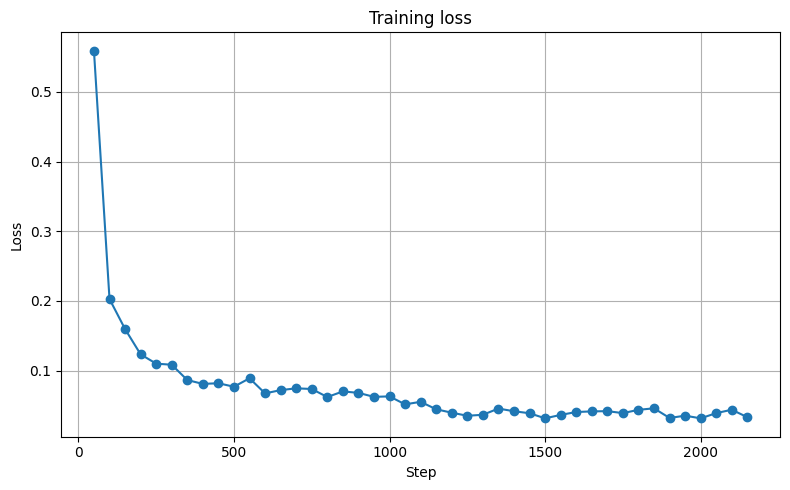

In [ ]:
log_history = pd.DataFrame(trainer.state.log_history)

display(log_history.tail())

loss_history = log_history.dropna(subset=["loss"]) if "loss" in log_history.columns else pd.DataFrame()

if len(loss_history) > 0:
    plt.figure(figsize=(8, 5))
    plt.plot(loss_history["step"], loss_history["loss"], marker="o")
    plt.title("Training loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Không có training loss để plot. Hãy giảm logging_steps nếu cần.")


## 10. Đánh giá trên dev set

In [ ]:
if DEV_HAS_LABELS:
    dev_output = trainer.predict(dev_dataset)

    dev_metrics = compute_metrics((dev_output.predictions, dev_output.label_ids))

    print("dev metrics:")
    for k, v in dev_metrics.items():
        print(f"{k}: {v:.4f}")

    dev_predictions, dev_true_labels = align_predictions(
        dev_output.predictions,
        dev_output.label_ids
    )

    print("\nClassification report on dev:")
    print(seq_classification_report(dev_true_labels, dev_predictions))

else:
    dev_output = trainer.predict(dev_dataset)

    dev_metrics = compute_metrics((dev_output.predictions, dev_output.label_ids))

    print("dev set không có gold label.")
    print("Metrics dưới đây được tính trên dev set:")
    for k, v in dev_metrics.items():
        print(f"{k}: {v:.4f}")

    dev_predictions, dev_true_labels = align_predictions(
        dev_output.predictions,
        dev_output.label_ids
    )

    print("\nClassification report on dev:")
    print(seq_classification_report(dev_true_labels, dev_predictions))

    dev_output = trainer.predict(dev_dataset)
    dev_pred_ids = np.argmax(dev_output.predictions, axis=2)

    print("\nĐã predict xong dev set, nhưng không có label thật để chấm điểm.")

dev set không có gold label.
Metrics dưới đây được tính trên dev set:
precision: 0.8316
recall: 0.8624
f1: 0.8467
accuracy: 0.9837

Classification report on dev:
               precision    recall  f1-score   support

     LOCATION       0.87      0.90      0.88      3098
MISCELLANEOUS       0.38      0.38      0.38       184
 ORGANIZATION       0.74      0.80      0.77      1883
       PERSON       0.89      0.91      0.90      2182

    micro avg       0.83      0.86      0.85      7347
    macro avg       0.72      0.74      0.73      7347
 weighted avg       0.83      0.86      0.85      7347




Đã predict xong dev set, nhưng không có label thật để chấm điểm.


## 11. Plot dev metrics

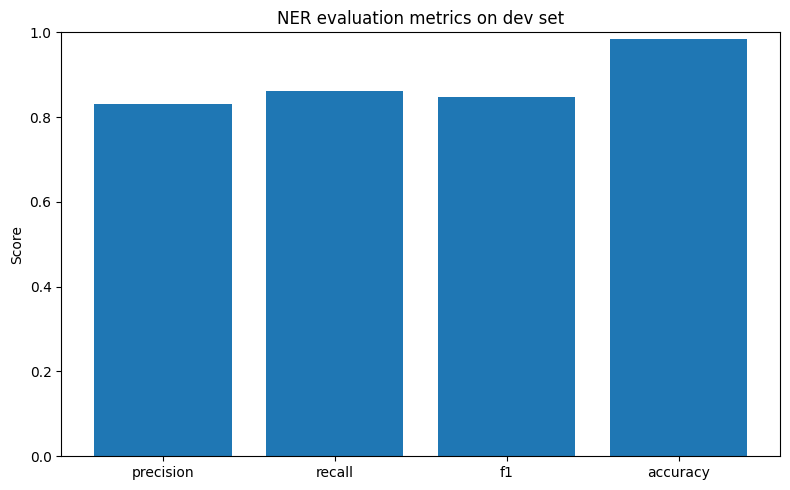

In [25]:
# Plot final metrics trên dev/test set

metric_source = dev_metrics   # hoặc test_metrics nếu bạn đặt tên là test_metrics

metric_names = list(metric_source.keys())
metric_values = [metric_source[m] for m in metric_names]

plt.figure(figsize=(8, 5))
plt.bar(metric_names, metric_values)
plt.ylim(0, 1)
plt.title("NER evaluation metrics on dev set")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

## 12. Plot F1 theo entity type

,entity,precision,recall,f1,support
3,PERSON,0.892280,0.911091,0.901587,2182
0,LOCATION,0.870110,0.897353,0.883521,3098
2,ORGANIZATION,0.744660,0.796070,0.769507,1883
1,MISCELLANEOUS,0.377049,0.375000,0.376022,184


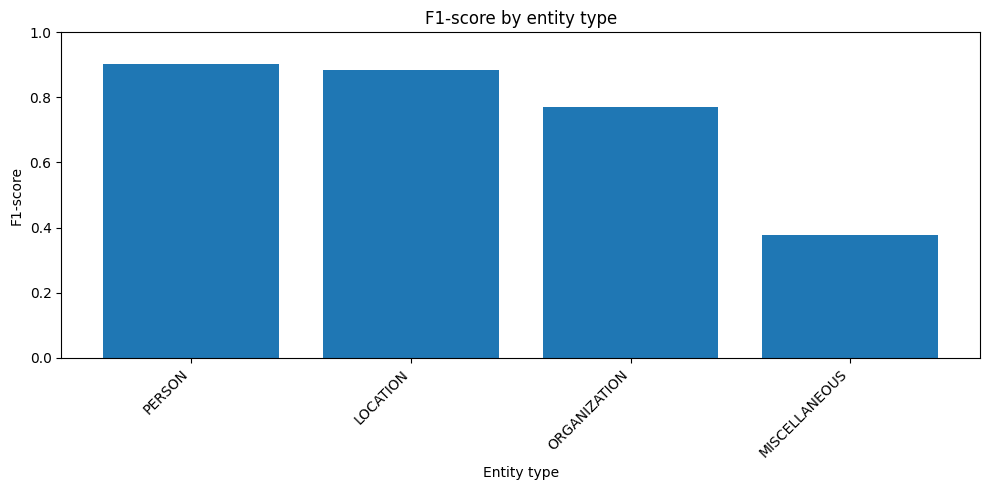

In [27]:
report_dict = seq_classification_report(
    dev_true_labels,
    dev_predictions,
    output_dict=True
)

entity_rows = []
for key, value in report_dict.items():
    if isinstance(value, dict) and key not in ["micro avg", "macro avg", "weighted avg"]:
        entity_rows.append({
            "entity": key,
            "precision": value.get("precision", 0),
            "recall": value.get("recall", 0),
            "f1": value.get("f1-score", 0),
            "support": value.get("support", 0),
        })

entity_df = pd.DataFrame(entity_rows).sort_values("f1", ascending=False)
display(entity_df)

if len(entity_df) > 0:
    plt.figure(figsize=(10, 5))
    plt.bar(entity_df["entity"], entity_df["f1"])
    plt.ylim(0, 1)
    plt.title("F1-score by entity type")
    plt.xlabel("Entity type")
    plt.ylabel("F1-score")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Không có entity-level report để plot.")
